In [ ]:
from datasets import load_dataset, load_from_disk
from typing import List, Tuple, Union
import gc
import json
import gc
import pandas as pd

BASE_PATH = "../../data/qa_datasets/"
DATASET_DIR_NAME = "natural_questions_train"

SAVE_DATASET_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/original"
SAVE_TMP_CONTEXTS_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/tmp_natural_questions_cntx.csv"
SAVE_CONTEXTS_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/relevant_contexts.csv"
SAVE_QA_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/qa_pairs.csv"
SAVE_STATS_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/stats.json"

DOC_MAX_LEN = 1024
DOC_MIN_LEN = 64
MAX_QA_PAIRS = 2000
NOISE_DOCUMENTS_AMOUNT = 2000

In [ ]:
from utils import preprocess_documents, plot_textlen_distribution, \
    preprocess_qapairs, select_noise_documents, calculate_dataset_stats, \
        check_dataset_consistency

In [ ]:
original_dataset = load_dataset("sentence-transformers/natural-questions", split="train") # 6k
original_dataset.save_to_disk(SAVE_DATASET_PATH)

In [ ]:
original_dataset

In [ ]:
original_dataset = load_from_disk(SAVE_DATASET_PATH)

In [ ]:
def get_question_documents(dataset: object, idx: int) -> List[Tuple[Union[None,str], str]]: 
    title = None
    text = dataset['answer'][idx]
    return [(title, text)]

def get_dataset_len(dataset: object) -> int:
    return len(dataset)

def get_qa_info(dataset: object, idx: int) -> Tuple[str, str, str, List[Tuple[Union[None, str], str]]]:
    question_type = None
    question, answer = dataset['query'][idx], dataset['answer'][idx]
    relevant_documents = [(None, dataset['answer'][idx])]
    return question, question_type, answer, relevant_documents

In [ ]:
CUSTOM_FUNCS = {
    'get_question_documents': get_question_documents,
    'get_dataset_len': get_dataset_len,
    'get_qa_info': get_qa_info
}

### Preprocessing documents

In [ ]:
accepted_documents_df = preprocess_documents(
    original_dataset, DOC_MIN_LEN, DOC_MAX_LEN, CUSTOM_FUNCS)
accepted_documents_df.to_csv(SAVE_TMP_CONTEXTS_PATH, index=False)

In [ ]:
plot_textlen_distribution(accepted_documents_df, 'context')

In [ ]:
accepted_documents_df.head()

In [ ]:
accepted_documents_df.info()

In [ ]:
accepted_documents_df.shape

### Preprocessing QA pairs

In [ ]:
qapairs_df, relevant_documents_df = preprocess_qapairs(
    original_dataset, accepted_documents_df, MAX_QA_PAIRS, CUSTOM_FUNCS)
qapairs_df.to_csv(SAVE_QA_PATH, index=False)

In [ ]:
plot_textlen_distribution(qapairs_df, 'answer')

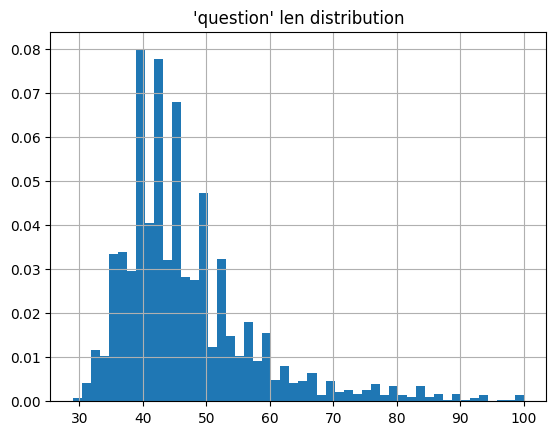

In [40]:
plot_textlen_distribution(qapairs_df, 'question')

In [ ]:
plot_textlen_distribution(relevant_documents_df, 'context')

In [ ]:
qapairs_df

In [ ]:
qapairs_df.info()

In [ ]:
qapairs_df.shape

In [ ]:
relevant_documents_df

In [ ]:
relevant_documents_df.info()

In [ ]:
relevant_documents_df.shape

### Expanding relevant documents dataframe by noise documents

In [ ]:
DOCIDX_OFFSET = max(relevant_documents_df['cntx_idx'].tolist()) + 1
print(DOCIDX_OFFSET)
noise_documents_df = select_noise_documents(
    relevant_documents_df, accepted_documents_df, 
    NOISE_DOCUMENTS_AMOUNT, DOCIDX_OFFSET, CUSTOM_FUNCS)

expanded_relevant_documents_df = pd.concat([relevant_documents_df, noise_documents_df], ignore_index=True)
expanded_relevant_documents_df.to_csv(SAVE_CONTEXTS_PATH, index=False)

In [ ]:
noise_documents_df

In [ ]:
noise_documents_df.info()

In [ ]:
noise_documents_df.shape

In [ ]:
plot_textlen_distribution(noise_documents_df, 'context')

In [ ]:
expanded_relevant_documents_df

In [ ]:
plot_textlen_distribution(expanded_relevant_documents_df, 'context')

### Calculating statistics

In [ ]:
processed_dataset_stats = calculate_dataset_stats(qapairs_df, expanded_relevant_documents_df)
processed_dataset_stats['NOISE_DOCUMENTS_AMOUNT'] = NOISE_DOCUMENTS_AMOUNT
with open(SAVE_STATS_PATH, 'w', encoding='utf-8') as fd:
    json.dump(processed_dataset_stats, fd, indent=1, ensure_ascii=False)

In [ ]:
check_dataset_consistency(original_dataset, qapairs_df, expanded_relevant_documents_df, CUSTOM_FUNCS)

In [ ]:
processed_dataset_stats